In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

In [23]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [24]:
SRC_DIR = "/content/drive/MyDrive/src"
image_paths = {"cat": os.path.join(SRC_DIR, "cat.jpg"), "airplane": os.path.join(SRC_DIR, "airplane.jpg"), "phone": os.path.join(SRC_DIR, "phone.jpg")}

In [25]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResNetBlock, self).__init__()
        # 1
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 2
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=1, stride=1, padding=0),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()
    def forward(self, x):
        shortcut = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += shortcut
        out = self.relu(out)
        return out

In [26]:
test_input = torch.randn(1, 3, 32, 32).to(DEVICE)
resnet_block = ResNetBlock(in_channels=3, out_channels=64).to(DEVICE)
test_output = resnet_block(test_input)
print(f"Input shape: {test_input.shape}, Output shape: {test_output.shape}")

Input shape: torch.Size([1, 3, 32, 32]), Output shape: torch.Size([1, 64, 32, 32])


In [27]:
class SimpleResNetModel(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleResNetModel, self).__init__()

        self.start = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.block1 = ResNetBlock(64, 64)
        self.block2 = ResNetBlock(64, 64)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.start(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
simple_resnet_model = SimpleResNetModel(num_classes=10).to(DEVICE)
print(simple_resnet_model)

SimpleResNetModel(
  (start): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (block1): ResNetBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (shortcut): Identity()
  )
  (block2): ResNetBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [28]:
test_input = torch.randn(1, 3, 32, 32).to(DEVICE)
with torch.no_grad():
    output = simple_resnet_model(test_input)
print("Размер входа:", test_input.shape)
print("Размер выхода:", output.shape)

Размер входа: torch.Size([1, 3, 32, 32])
Размер выхода: torch.Size([1, 10])


**Задание 2**

In [29]:
mobilenet_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
mobilenet_model = mobilenet_model.to(DEVICE)
mobilenet_model.eval()
print("MobileNetV2 успешно загружена")

MobileNetV2 успешно загружена


In [30]:
weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
imagenet_classes = weights.meta["categories"]

print("Количество классов ImageNet:", len(imagenet_classes))
print("Первые 10 классов:", imagenet_classes[:10])

Количество классов ImageNet: 1000
Первые 10 классов: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']


In [31]:
preprocess = weights.transforms()

print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [32]:
def load_and_prepare_image(img_path):
    img = Image.open(img_path).convert("RGB")
    input_tensor = preprocess(img)
    input_batch = input_tensor.unsqueeze(0)
    return img, input_batch

Файл: cat
Путь: /content/drive/MyDrive/src/cat.jpg


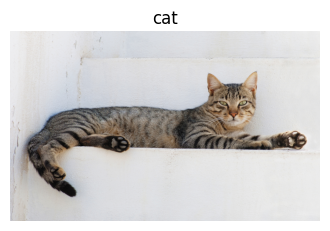

Top-3 предсказания MobileNetV2:
1. tabby — вероятность: 0.5600
2. Egyptian cat — вероятность: 0.2222
3. tiger cat — вероятность: 0.2112
Файл: airplane
Путь: /content/drive/MyDrive/src/airplane.jpg


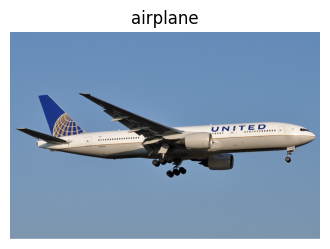

Top-3 предсказания MobileNetV2:
1. airliner — вероятность: 0.9662
2. wing — вероятность: 0.0317
3. warplane — вероятность: 0.0013
Файл: phone
Путь: /content/drive/MyDrive/src/phone.jpg


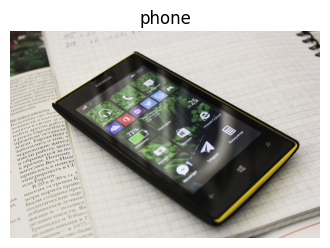

Top-3 предсказания MobileNetV2:
1. cellular telephone — вероятность: 0.7309
2. iPod — вероятность: 0.2397
3. hand-held computer — вероятность: 0.0124


In [33]:
for image_name, img_path in image_paths.items():
    print("Файл:", image_name)
    print("Путь:", img_path)
    if not os.path.exists(img_path):
        print("Файл не найден. Проверь путь и название файла.")
        continue
    original_img, input_batch = load_and_prepare_image(img_path)
    input_batch = input_batch.to(DEVICE)
    plt.figure(figsize=(4, 4))
    plt.imshow(original_img)
    plt.axis("off")
    plt.title(image_name)
    plt.show()
    with torch.no_grad():
        outputs = mobilenet_model(input_batch)

        probabilities = F.softmax(outputs[0], dim=0)

        top3_probabilities, top3_indices = torch.topk(probabilities, 3)

    print("Top-3 предсказания MobileNetV2:")

    for i in range(3):
        class_index = top3_indices[i].item()
        class_name = imagenet_classes[class_index]
        probability = top3_probabilities[i].item()

        print(f"{i + 1}. {class_name} — вероятность: {probability:.4f}")